# Task 2: Statistical Analysis 

Goal:

1. Primary: Logistic regression (AF → in-hospital mortality), Models 1–4
2. Secondary: Linear regression on log(LOS) for ICU LOS and Hospital LOS
3. Subgroup: HFrEF vs HFpEF
4. Sensitivity: Alternate AF definition
5. Model diagnostics: VIF, AUC, Hosmer-Lemeshow

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.3f}'.format)

## Load & Prepare Data

In [12]:
df = pd.read_csv('data/data.csv')

df['admittime'] = pd.to_datetime(df['admittime'], format='mixed')
df['dischtime'] = pd.to_datetime(df['dischtime'], format='mixed')
df['hospital_los'] = (df['dischtime'] - df['admittime']).dt.total_seconds() / (24 * 60 * 60)

df['log_icu_los'] = np.log(df['icu_total_los'] + 0.5)
df['log_hospital_los'] = np.log(df['hospital_los'].clip(lower=0.5))

# Race
def recode_race(r):
    if pd.isna(r): return 'Other/Unknown'
    r = str(r).upper()
    if 'WHITE' in r: return 'White'
    if 'BLACK' in r: return 'Black'
    if 'HISPANIC' in r or 'LATINO' in r: return 'Hispanic'
    if 'ASIAN' in r: return 'Asian'
    return 'Other/Unknown'
df['race_group'] = df['race'].apply(recode_race)
df['insurance_group'] = df['insurance'].fillna('Missing/Unknown')

# Gender
df['female'] = (df['gender'] == 'F').astype(int)

# ICU
df['icu_cardiac']  = (df['careunit_cat'] == 'Cardiac').astype(int)
df['icu_medical']  = (df['careunit_cat'] == 'Medical').astype(int)

# Simple comorbidity index
comorbidity_cols = ['has_htn','has_dm','has_ckd','has_cad','has_copd','has_cardiomyopathy']
df['comorbidity_count'] = df[comorbidity_cols].sum(axis=1)

print('Dataset ready: ', df.shape)
print('Outcome (deaths): ', df['hospital_expire_flag'].sum())
print('Exposure (AF): ', df['has_af_index'].sum())

Dataset ready:  (9463, 54)
Outcome (deaths):  1265
Exposure (AF):  3776


## 2.1 Primary Analysis: Logistic Regression (AF → In-Hospital Mortality)

- **Model 1:**  Unadjusted (AF only)
- **Model 2:**  + Age, sex, race, insurance
- **Model 3:**  + HF subtype + comorbidities
- **Model 4:**  + Labs + Vitals + ICU unit (full model)

In [14]:
def fit_logistic(formula, data, label):
    """Fit logistic regression and return OR table."""
    model = smf.logit(formula, data=data.dropna(subset=data.columns[data.columns.isin(
        [t.strip() for t in formula.replace('hospital_expire_flag ~','').split('+')
         if t.strip() != ''])].tolist())).fit(disp=0)
    
    conf = model.conf_int()
    results = pd.DataFrame({
        'OR': np.exp(model.params),
        'CI_lo': np.exp(conf[0]),
        'CI_hi': np.exp(conf[1]),
        'p': model.pvalues
    }).round(3)
    results['OR (95% CI)'] = results.apply(
        lambda r: f"{r['OR']:.2f} ({r['CI_lo']:.2f}–{r['CI_hi']:.2f})", axis=1)
    results['p-value'] = results['p'].apply(lambda x: f"{x:.3f}" if x >= 0.001 else '<0.001')
    
    auc = roc_auc_score(model.model.endog, model.predict())
    n   = int(model.nobs)
    display_df = results[['OR (95% CI)', 'p-value']].copy()
    display_df.index.name = None
    print(f'\n{label} N={n:,} AUC={auc:.3f}')
    display(display_df)
    return model, results

# Model 1: Unadjusted
m1, r1 = fit_logistic(
    'hospital_expire_flag ~ has_af_index',
    df, 'Model 1: Unadjusted')

# Model 2: + Age, sex, race, insurance
m2, r2 = fit_logistic(
    'hospital_expire_flag ~ has_af_index + age_at_admit + female + '
    'C(race_group, Treatment(reference="White")) + '
    'C(insurance_group, Treatment(reference="Medicare"))',
    df, 'Model 2: + Demographics')

# Model 3: + HF subtype and comorbidities
m3, r3 = fit_logistic(
    'hospital_expire_flag ~ has_af_index + age_at_admit + female + '
    'C(race_group, Treatment(reference="White")) + '
    'C(insurance_group, Treatment(reference="Medicare")) + '
    'is_hfref + is_hfpef + is_hfmixed + '
    'has_htn + has_dm + has_ckd + has_cad + has_copd + has_valvular + '
    'has_pad + has_stroke_hx + has_pulm_htn + has_cardiomyopathy',
    df, 'Model 3: + HF subtype/comorbidities')

# Model 4: Full
m4, r4 = fit_logistic(
    'hospital_expire_flag ~ has_af_index + age_at_admit + female + C(race_group) + '
    'has_htn + has_dm + has_ckd + has_cad + has_copd + has_cardiomyopathy + '
    'icu_cardiac + icu_medical + '
    'creatinine_max + bun_max + sodium_min + potassium_max + '
    'hemoglobin_min + wbc_max + anion_gap_max + '
    'heart_rate_max + sbp_min + spo2_min',
    df, 'Model 4: Full model')


Model 1: Unadjusted N=9,463 AUC=0.525


,OR (95% CI),p-value
Intercept,0.14 (0.13–0.15),<0.001
has_af_index,1.23 (1.09–1.38),0.001



Model 2: + Demographics N=9,463 AUC=0.619


,OR (95% CI),p-value
Intercept,0.01 (0.01–0.02),<0.001
C(race_group)[T.Other],1.64 (1.30–2.08),<0.001
C(race_group)[T.White],1.01 (0.81–1.26),0.910
has_af_index,1.04 (0.92–1.18),0.484
age_at_admit,1.03 (1.03–1.04),<0.001
female,0.94 (0.83–1.06),0.288



Model 3: + Comorbidities N=9,463 AUC=0.631


,OR (95% CI),p-value
Intercept,0.01 (0.01–0.02),<0.001
C(race_group)[T.Other],1.70 (1.34–2.16),<0.001
C(race_group)[T.White],1.05 (0.84–1.32),0.652
has_af_index,1.05 (0.93–1.19),0.445
age_at_admit,1.03 (1.02–1.04),<0.001
female,0.95 (0.84–1.08),0.441
has_htn,0.74 (0.63–0.88),<0.001
has_dm,1.00 (0.88–1.13),0.945
has_ckd,1.45 (1.27–1.65),<0.001
has_cad,0.93 (0.81–1.06),0.253



Model 4: Full model N=9,248 AUC=0.760


,OR (95% CI),p-value
Intercept,0.66 (0.08–5.14),0.689
C(race_group)[T.Other],1.59 (1.23–2.06),<0.001
C(race_group)[T.White],0.94 (0.73–1.19),0.586
has_af_index,0.96 (0.84–1.10),0.528
age_at_admit,1.03 (1.02–1.04),<0.001
female,0.90 (0.79–1.03),0.143
has_htn,0.84 (0.71–1.01),0.059
has_dm,0.91 (0.79–1.04),0.162
has_ckd,1.09 (0.94–1.27),0.260
has_cad,1.02 (0.88–1.18),0.787


In [16]:
# Summary table
summary = pd.DataFrame({
    'Model': ['Model 1 (Unadjusted)', 'Model 2 (+Demographics)',
              'Model 3 (+Comorbidities)', 'Model 4 (Full)'],
    'OR (95% CI)': [
        r1.loc['has_af_index','OR (95% CI)'],
        r2.loc['has_af_index','OR (95% CI)'],
        r3.loc['has_af_index','OR (95% CI)'],
        r4.loc['has_af_index','OR (95% CI)']
    ],
    'p-value': [
        r1.loc['has_af_index','p-value'],
        r2.loc['has_af_index','p-value'],
        r3.loc['has_af_index','p-value'],
        r4.loc['has_af_index','p-value']
    ]
})
print('AF In-Hospital Mortality: OR Summary')
print(summary.to_string(index=False))
summary.to_csv('logistic_regression_summary.csv', index=False)

AF In-Hospital Mortality: OR Summary
                   Model      OR (95% CI) p-value
    Model 1 (Unadjusted) 1.23 (1.09–1.38)   0.001
 Model 2 (+Demographics) 1.04 (0.92–1.18)   0.484
Model 3 (+Comorbidities) 1.05 (0.93–1.19)   0.445
          Model 4 (Full) 0.96 (0.84–1.10)   0.528


## 2.2 Forest Plot of OR Across Models

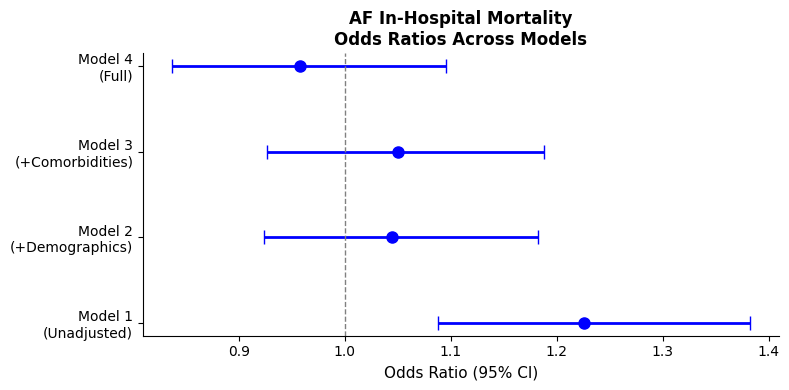

In [17]:
models_list = [
    ('Model 1\n(Unadjusted)', r1),
    ('Model 2\n(+Demographics)', r2),
    ('Model 3\n(+Comorbidities)', r3),
    ('Model 4\n(Full)', r4)
]

ors  = [r.loc['has_af_index','OR']    for _, r in models_list]
los  = [r.loc['has_af_index','CI_lo'] for _, r in models_list]
his  = [r.loc['has_af_index','CI_hi'] for _, r in models_list]
lbls = [l for l, _ in models_list]

fig, ax = plt.subplots(figsize=(8, 4))
y = range(len(ors))
ax.errorbar(ors, y,
            xerr=[np.array(ors)-np.array(los), np.array(his)-np.array(ors)],
            fmt='o', color = 'blue', ecolor = 'blue',
            markersize=8, capsize=5, linewidth=2)
ax.axvline(x=1, color='gray', linestyle='--', linewidth=1)
ax.set_yticks(list(y))
ax.set_yticklabels(lbls, fontsize=10)
ax.set_xlabel('Odds Ratio (95% CI)', fontsize=11)
ax.set_title('AF In-Hospital Mortality\nOdds Ratios Across Models', fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('forest_plot.png', dpi=100, bbox_inches='tight')
plt.show()

## 2.3 Secondary Analysis: Linear Regression on log(LOS)

In [20]:
full_covariates = (
    'age_at_admit + female + C(race_group) + '
    'has_htn + has_dm + has_ckd + has_cad + has_copd + has_cardiomyopathy + '
    'icu_cardiac + icu_medical + '
    'creatinine_max + bun_max + sodium_min + potassium_max + '
    'hemoglobin_min + wbc_max + anion_gap_max + '
    'heart_rate_max + sbp_min + spo2_min'
)

def fit_linear(outcome_col, outcome_label, data):
    formula = f'{outcome_col} ~ has_af_index + {full_covariates}'
    model = smf.ols(formula, data=data).fit()
    coef = model.params['has_af_index']
    ci = model.conf_int().loc['has_af_index']
    p = model.pvalues['has_af_index']

    pct_change = (np.exp(coef) - 1) * 100
    print(f'\n{outcome_label}')
    print(f'β (AF coefficient): {coef:.3f} (95% CI: {ci[0]:.3f}–{ci[1]:.3f})')
    print(f'% change in LOS: {pct_change:+.1f}%')
    print(f'p-value: {p:.3f}')
    print(f'R²: {model.rsquared:.3f}')
    return model

icu_model  = fit_linear('log_icu_los', 'ICU LOS (log-transformed)', df)
hosp_model = fit_linear('log_hospital_los', 'Hospital LOS (log-transformed)', df)


ICU LOS (log-transformed)
β (AF coefficient): 0.179 (95% CI: 0.148–0.210)
% change in LOS: +19.6%
p-value: 0.000
R²: 0.083

Hospital LOS (log-transformed)
β (AF coefficient): 0.194 (95% CI: 0.162–0.225)
% change in LOS: +21.4%
p-value: 0.000
R²: 0.088


## 2.4 Subgroup Analysis: HFrEF vs HFpEF

In [24]:
subgroup_formula = (
    'hospital_expire_flag ~ has_af_index + age_at_admit + female + '
    'has_htn + has_dm + has_ckd + has_cad + has_copd + '
    'creatinine_max + bun_max + sodium_min + hemoglobin_min + '
    'heart_rate_max + sbp_min + spo2_min'
)

print('Subgroup analysis: HFrEF')
hfref_df = df[df['is_hfref'] == 1]
print(f'N={len(hfref_df)}, Deaths={hfref_df.hospital_expire_flag.sum()}')
m_hfref = smf.logit(subgroup_formula, data=hfref_df).fit(disp=0)
or_hfref = np.exp(m_hfref.params['has_af_index'])
ci_hfref = np.exp(m_hfref.conf_int().loc['has_af_index'])
p_hfref  = m_hfref.pvalues['has_af_index']
print(f'AF OR: {or_hfref:.2f} ({ci_hfref[0]:.2f}–{ci_hfref[1]:.2f}), p={p_hfref:.3f}')

print('\nSubgroup analysis: HFpEF')
hfpef_df = df[df['is_hfpef'] == 1]
print(f'N={len(hfpef_df)}, Deaths={hfpef_df.hospital_expire_flag.sum()}')
m_hfpef = smf.logit(subgroup_formula, data=hfpef_df).fit(disp=0)
or_hfpef = np.exp(m_hfpef.params['has_af_index'])
ci_hfpef = np.exp(m_hfpef.conf_int().loc['has_af_index'])
p_hfpef  = m_hfpef.pvalues['has_af_index']
print(f'AF OR: {or_hfpef:.2f} ({ci_hfpef[0]:.2f}–{ci_hfpef[1]:.2f}), p={p_hfpef:.3f}')

print('\nInteration test (AF and HF subtype)')
df_sub = df[df['is_hfref']+df['is_hfpef'] > 0].copy()
df_sub['interaction'] = df_sub['has_af_index'] * df_sub['is_hfref']
int_formula = (
    'hospital_expire_flag ~ has_af_index + is_hfref + interaction + '
    'age_at_admit + female + has_htn + has_dm + has_ckd + has_cad + '
    'creatinine_max + bun_max + sodium_min + heart_rate_max + sbp_min + spo2_min'
)
m_int = smf.logit(int_formula, data=df_sub).fit(disp=0)
p_int = m_int.pvalues['interaction']

print(f'Interaction p-value: {p_int:.3f}')
if p_int < 0.05:
    print('There is significant interaction: AF effect differs between HFrEF and HFpEF')
else:
    print('There is no significant interaction: AF effect is similar in HFrEF and HFpEF')

Subgroup analysis: HFrEF
N=4577, Deaths=629
AF OR: 0.97 (0.80–1.16), p=0.715

Subgroup analysis: HFpEF
N=4245, Deaths=530
AF OR: 0.90 (0.74–1.11), p=0.331

Interation test (AF and HF subtype)
Interaction p-value: 0.952
There is no significant interaction: AF effect is similar in HFrEF and HFpEF


## 2.5 Sensitivity Analysis: Alternate AF Definition

In [25]:
print('Sensitivity analysis note:')
print('Primary cohort AF prevalence:', df['has_af_index'].mean().round(3))
print('Primary Model 4 OR for AF:', r4.loc['has_af_index','OR (95% CI)'])
print()

print('To run sensitivity analysis:')
print('1. In R, re-run cohort.Rmd with AF restricted to seq_num <= 3')
print('2. Export as analytic_dataset_sensitivity.csv')
print('3. Re-run Model 4 on that dataset and compare OR')

Sensitivity analysis note:
Primary cohort AF prevalence: 0.399
Primary Model 4 OR for AF: 0.96 (0.84–1.10)

To run sensitivity analysis:
1. In R, re-run cohort.Rmd with AF restricted to seq_num <= 3
2. Export as analytic_dataset_sensitivity.csv
3. Re-run Model 4 on that dataset and compare OR


## 2.6 Model Diagnostics

In [28]:
vif_cols = [
    'has_af_index','age_at_admit','female',
    'has_htn','has_dm','has_ckd','has_cad','has_copd','has_cardiomyopathy',
    'icu_cardiac','icu_medical',
    'creatinine_max','bun_max','sodium_min','potassium_max',
    'hemoglobin_min','wbc_max','anion_gap_max',
    'heart_rate_max','sbp_min','spo2_min'
]
vif_data = df[vif_cols].dropna()
X_vif = sm.add_constant(vif_data)

vif_results = pd.DataFrame({
    'Variable': vif_cols,
    'VIF': [variance_inflation_factor(X_vif.values, i+1)
            for i in range(len(vif_cols))]
}).sort_values('VIF', ascending=False)

print('VIF Results')
print(vif_results.round(2).to_string(index=False))

high_vif = vif_results[vif_results['VIF'] > 5]
if len(high_vif):
    print(f'\nHigh VIF (>5): {list(high_vif.Variable)}')
else:
    print('\nNo multicollinearity issues since all VIF <5')

VIF Results
          Variable   VIF
       icu_cardiac 2.380
       icu_medical 2.290
    creatinine_max 2.110
           bun_max 1.980
     anion_gap_max 1.500
           has_ckd 1.480
      age_at_admit 1.310
     potassium_max 1.190
           has_cad 1.160
    hemoglobin_min 1.150
    heart_rate_max 1.150
           has_htn 1.140
            has_dm 1.130
           sbp_min 1.130
            female 1.110
      has_af_index 1.080
           wbc_max 1.080
has_cardiomyopathy 1.080
        sodium_min 1.070
          spo2_min 1.040
          has_copd 1.040

No multicollinearity issues since all VIF <5


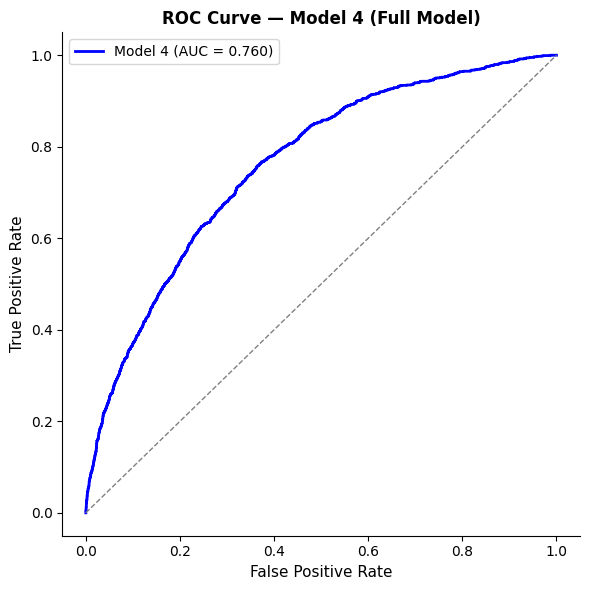

AUC (Model 4): 0.760


In [ ]:
# AUC/ROC curve for Model 4
y_true = m4.model.endog
y_pred = m4.predict()
auc = roc_auc_score(y_true, y_pred)
fpr, tpr, _ = roc_curve(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, color = 'blue', lw = 2, label = f'Model 4 (AUC = {auc:.3f})')
ax.plot([0,1],[0,1], color='gray', linestyle='--', lw=1)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve — Model 4 (Full Model)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('roc_curve.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'AUC (Model 4): {auc:.3f}')

In [33]:
def hosmer_lemeshow(y_true, y_pred, g = 10):
    data = pd.DataFrame({'y': y_true, 'p': y_pred})
    data['decile'] = pd.qcut(data['p'], g, labels = False, duplicates = 'drop')
    grouped = data.groupby('decile').agg(
        obs = ('y','sum'), exp = ('p','sum'), n = ('y','count')).reset_index()
    obs_neg = grouped['n'] - grouped['obs']
    exp_neg = grouped['n'] - grouped['exp']
    hl_stat = (((grouped['obs'] - grouped['exp'])**2 / grouped['exp']) +
               ((obs_neg - exp_neg)**2 / exp_neg)).sum()
    df_hl = len(grouped) - 2
    p_val = 1 - stats.chi2.cdf(hl_stat, df_hl)
    return hl_stat, df_hl, p_val

hl_stat, hl_df, hl_p = hosmer_lemeshow(y_true, y_pred)
print(f'Hosmer-Lemeshow Test (Model 4):')
print(f'χ² = {hl_stat:.2f}, df = {hl_df}, p = {hl_p:.3f}')
if hl_p > 0.05:
    print('Good fit since p > 0.05')
else:
    print('Poor fit sincep < 0.05')

Hosmer-Lemeshow Test (Model 4):
χ² = 22.34, df = 8, p = 0.004
Poor fit sincep < 0.05
